<a href="https://colab.research.google.com/github/lecacung-ai/TH_DeepLearning/blob/main/BUOI3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

NẠP THƯ VIỆN

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
import keras
from keras.layers import Conv2D, Dense, MaxPool2D, Flatten
from keras.models import Sequential
from keras import Input
import matplotlib.pyplot as plt

ĐỌC DỮ LIỆU MNIST TỪ FILE CSV

In [ ]:
mnist_train = '/content/sample_data/mnist_train_small.csv'
mnist_test = '/content/sample_data/mnist_test.csv'

df_train = pd.read_csv(mnist_train)
df_test = pd.read_csv(mnist_test)
print(df_train.shape)

X_train = df_train.iloc[:, 1:]
y_train = df_train.iloc[:, 0]
X_test = df_test.iloc[:, 1:]
y_test = df_test.iloc[:, 0]
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

num_classes = 10
input_shape = (28, 28, 1)

X_train = X_train.astype("float32") / 255
X_test = X_test.astype("float32") / 255

X_train = X_train.to_numpy()
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1)
print(X_train.shape)

X_test = X_test.to_numpy()
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1)
print(X_test.shape)

print('Number of classes:', len(np.unique(y_train)))
print('Classes:', np.unique(y_train))
print(y_train[:5])

(19999, 785)
(19999, 784) (19999,) (9999, 784) (9999,)
(19999, 28, 28, 1)
(9999, 28, 28, 1)
Number of classes: 10
Classes: [0 1 2 3 4 5 6 7 8 9]
0    5
1    7
2    9
3    5
4    2
Name: 6, dtype: int64


TRỰC QUAN 10 ẢNH ĐẦU

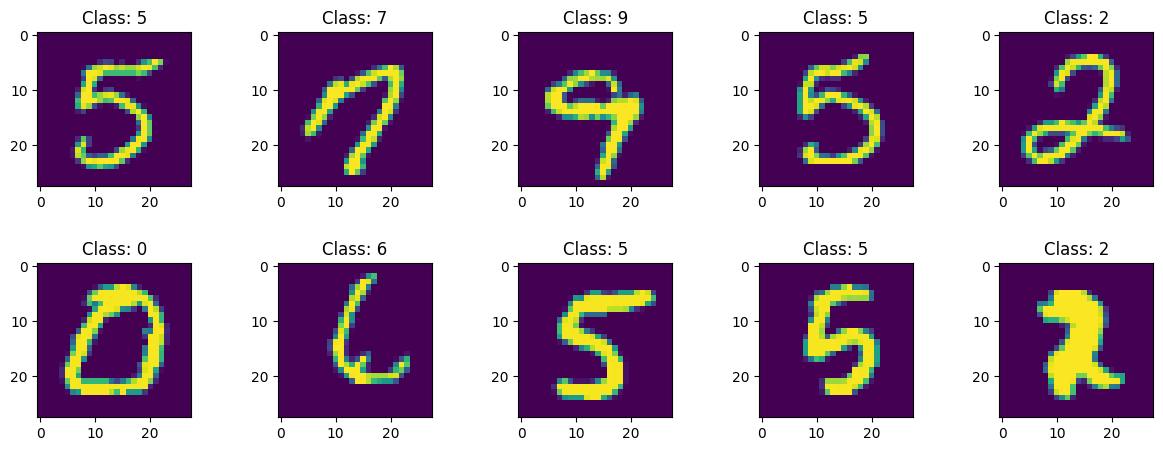

In [ ]:
#Data visualization
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(15, 5))
ax = axes.ravel()
for i in range(10):
    ax[i].imshow(X_train[i].reshape(28, 28))
    ax[i].title.set_text("Class: " + str(y_train[i]))
plt.subplots_adjust(hspace=0.5)
plt.show()

CHUYỂN GIÁ TRỊ NHÃN THÀNH ONE-HOT ENCODING


In [ ]:
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

XÂY DỰNG MÔ HÌNH CNN

In [ ]:
model = Sequential()
model.add(Input(shape=input_shape))
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(Dense(units=10, activation='softmax'))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

HUẤN LUYỆN CNN

In [ ]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_fit = model.fit(X_train, y_train, batch_size=128, epochs=15, validation_split=0.1, verbose=1)

Epoch 1/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 15s 97ms/step - accuracy: 0.8398 - loss: 0.6099 - val_accuracy: 0.9315 - val_loss: 0.2278
Epoch 2/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 15s 104ms/step - accuracy: 0.9577 - loss: 0.1413 - val_accuracy: 0.9595 - val_loss: 0.1286
Epoch 3/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 20s 99ms/step - accuracy: 0.9731 - loss: 0.0909 - val_accuracy: 0.9705 - val_loss: 0.0959
Epoch 4/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 21s 99ms/step - accuracy: 0.9778 - loss: 0.0707 - val_accuracy: 0.9755 - val_loss: 0.0825
Epoch 5/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 14s 100ms/step - accuracy: 0.9818 - loss: 0.0576 - val_accuracy: 0.9785 - val_loss: 0.0775
Epoch 6/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 17s 122ms/step - accuracy: 0.9858 - loss: 0.0454 - val_accuracy: 0.9770 - val_loss: 0.0768
Epoch 7/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 14s 101ms/step - accuracy: 0.9869 - loss: 0.0404 - val_accuracy: 0.9795 - val_loss: 0.0720
Epoch 8/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 14s 96ms/step - accuracy: 0.9891 - loss: 0.034

ĐÁNH GIÁ QUA ĐỒ THỊ

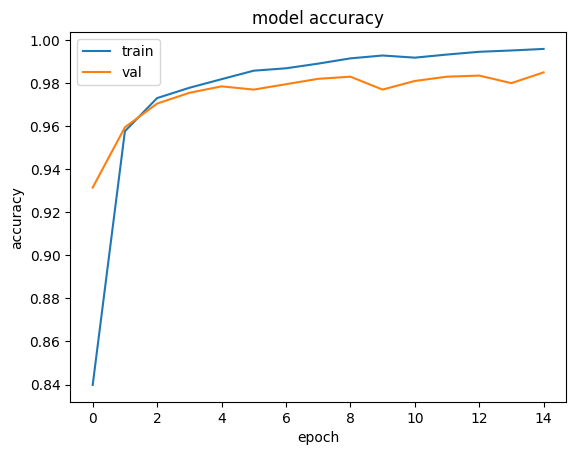

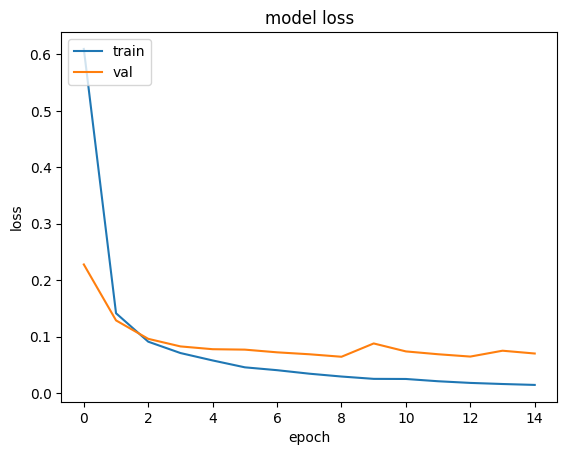

In [ ]:
plt.plot(model_fit.history['accuracy'])
plt.plot(model_fit.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

plt.plot(model_fit.history['loss'])
plt.plot(model_fit.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

ĐÁNH GIÁ TRÊN TẬP TEST

In [ ]:
score = model.evaluate(X_test, y_test, verbose=2)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

313/313 - 2s - 8ms/step - accuracy: 0.9844 - loss: 0.0551
Test loss: 0.055074628442525864
Test accuracy: 0.9843984246253967


DỰ BÁO NHÃN CHO ẢNH SD CNN, LƯU THAM SỐ MÔ HÌNH

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
[[6.4925111e-06 4.5790897e-05 9.9994779e-01 1.3326582e-11 6.5878674e-20
  7.8425188e-15 8.7327345e-09 1.9217130e-18 4.5013091e-09 1.3884771e-20]]
2 2


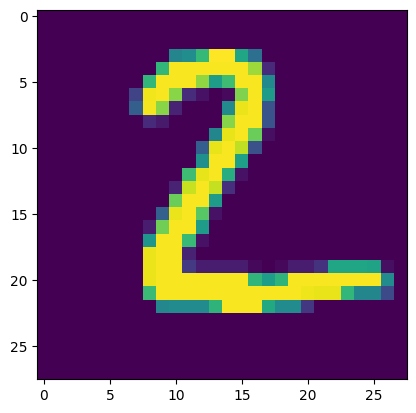

In [ ]:
predict = model.predict(X_test[:1])
print(predict)
print(np.argmax(predict), np.argmax(y_test[0]))
plt.imshow(X_test[:1].reshape(28, 28))
plt.show()

model.save_weights('cnn.weights.h5')

NẠP LẠI MÔ HÌNH VÀ THAM SỐ

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 328ms/step
[[3.22694511e-08 9.99951005e-01 1.02775821e-05 9.18088361e-08
  2.50695612e-05 1.08743443e-07 3.93803020e-07 5.66706876e-06
  7.33715933e-06 1.09716325e-08]]
1 1


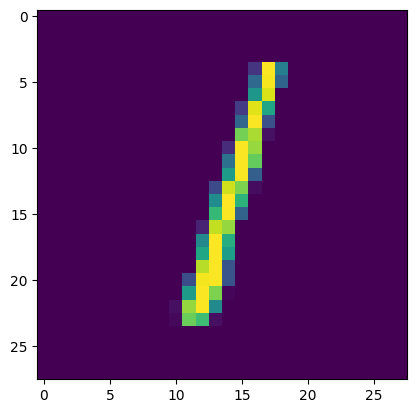

In [ ]:
model = Sequential()
model.add(Input(shape=input_shape))
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(Dense(units=10, activation='softmax'))

model.load_weights('cnn.weights.h5')

predict = model.predict(X_test[1:2])
print(predict)
print(np.argmax(predict), np.argmax(y_test[1]))
plt.imshow(X_test[1:2].reshape(28, 28))
plt.show()

Bài 1:

NẠP THƯ VIỆN

In [13]:
import numpy as np
import pandas as pd
import tensorflow as tf
import keras
from keras.models import Sequential
from keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Dropout
from keras.utils import to_categorical
import matplotlib.pyplot as plt

NẠP VÀ XỬ LÝ DỮ LIỆU

In [14]:
from keras.datasets import cifar10
(X_train, y_train), (X_test, y_test) = cifar10.load_data()
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0
print("Kích thước tập huấn luyện X_train:", X_train.shape)
print("Kích thước tập kiểm tra X_test:", X_test.shape)
num_classes = 10
y_train = to_categorical(y_train, num_classes)
y_test = to_categorical(y_test, num_classes)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step
Kích thước tập huấn luyện X_train: (50000, 32, 32, 3)
Kích thước tập kiểm tra X_test: (10000, 32, 32, 3)


TRỰC QUAN HOÁ DỮ LIỆU

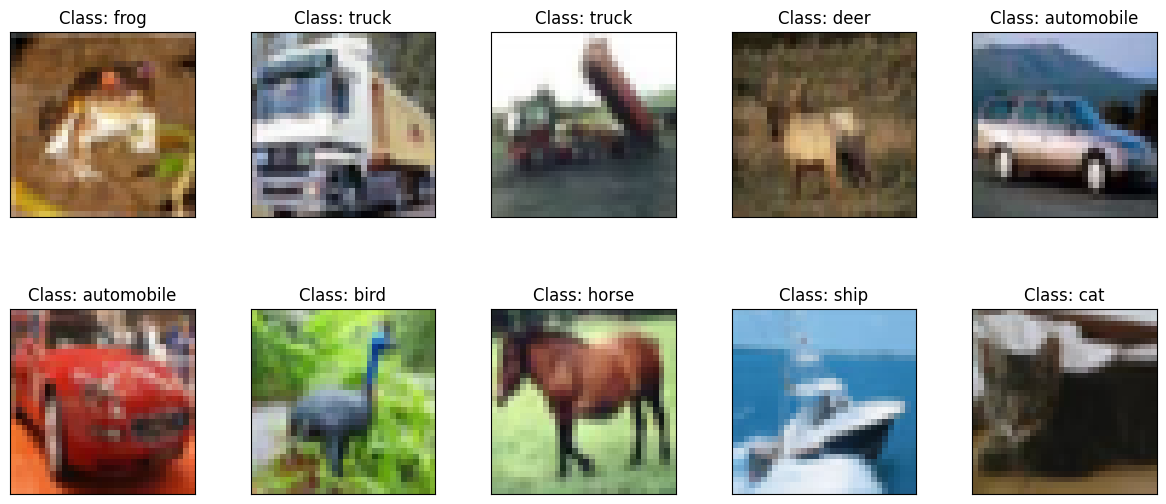

In [15]:
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(15, 6))
ax = axes.ravel()
for i in range(10):
    ax[i].imshow(X_train[i])
    # Lấy nhãn gốc bằng cách tìm vị trí số 1 trong vector mã hóa one-hot
    current_label_idx = np.argmax(y_train[i])
    ax[i].title.set_text(f"Class: {class_names[current_label_idx]}")
    ax[i].get_xaxis().set_visible(False)
    ax[i].get_yaxis().set_visible(False)
plt.subplots_adjust(hspace=0.5)
plt.show()

XÂY DỰNG CNN CHO ẢNH MÀU

In [16]:
model = Sequential()
model.add(Conv2D(filters=32, kernel_size=(3, 3), activation='relu', input_shape=(32, 32, 3)))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(0.25))
model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2))) # [cite: 878]
model.add(Dropout(0.25))
model.add(Flatten())
model.add(Dense(units=128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(units=num_classes, activation='softmax'))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 315,722 (1.20 MB)

 Trainable params: 315,722 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

HUẤN LUYỆN MÔ HÌNH

In [17]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_fit = model.fit(X_train, y_train, batch_size=64, epochs=10, validation_split=0.1, verbose=1)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 70s 97ms/step - accuracy: 0.3753 - loss: 1.6999 - val_accuracy: 0.5304 - val_loss: 1.3435
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 77s 90ms/step - accuracy: 0.4960 - loss: 1.4057 - val_accuracy: 0.5828 - val_loss: 1.1940
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 64s 92ms/step - accuracy: 0.5332 - loss: 1.3070 - val_accuracy: 0.6006 - val_loss: 1.1322
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 65s 92ms/step - accuracy: 0.5584 - loss: 1.2370 - val_accuracy: 0.6302 - val_loss: 1.0641
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 91ms/step - accuracy: 0.5874 - loss: 1.1799 - val_accuracy: 0.6620 - val_loss: 0.9880
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 63s 90ms/step - accuracy: 0.5991 - loss: 1.1394 - val_accuracy: 0.6742 - val_loss: 0.9638
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 63s 90ms/step - accuracy: 0.6089 - loss: 1.1095 - val_accuracy: 0.6828 - val_loss: 0.9312
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 64s 91ms/step - accuracy: 0.6211 - loss: 1.0784 - 

ĐÁNH GIÁ ĐỘ CHÍNH XÁC VÀ LƯU THAM SỐ WEIGHTS

313/313 - 4s - 12ms/step - accuracy: 0.6786 - loss: 0.9212

[KẾT QUẢ TẬP TEST] Độ mất mát (Loss): 0.9212
[KẾT QUẢ TẬP TEST] Độ chính xác (Accuracy): 67.86%
Đã lưu tham số mô hình vào tệp cnn_cifar10.weights.h5


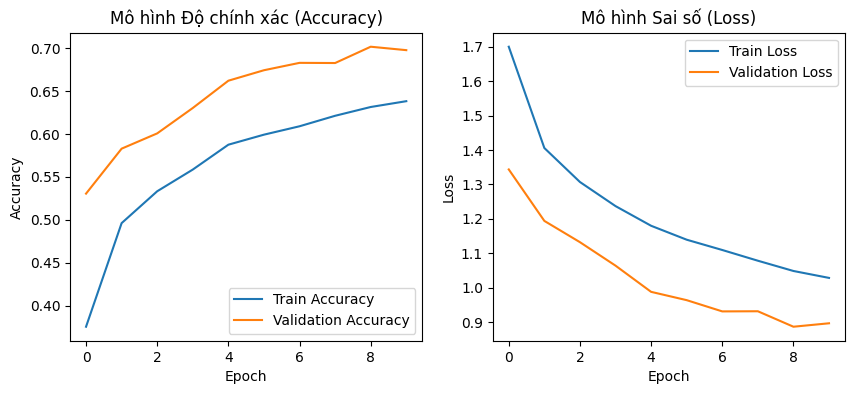

In [20]:
score = model.evaluate(X_test, y_test, verbose=2)
print(f"\n[KẾT QUẢ TẬP TEST] Độ mất mát (Loss): {score[0]:.4f}")
print(f"[KẾT QUẢ TẬP TEST] Độ chính xác (Accuracy): {score[1]*100:.2f}%")
model.save_weights('cnn_cifar10.weights.h5')
print("Đã lưu tham số mô hình vào tệp cnn_cifar10.weights.h5")
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(model_fit.history['accuracy'], label='Train Accuracy')
plt.plot(model_fit.history['val_accuracy'], label='Validation Accuracy')
plt.title('Mô hình Độ chính xác (Accuracy)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(model_fit.history['loss'], label='Train Loss')
plt.plot(model_fit.history['val_loss'], label='Validation Loss')
plt.title('Mô hình Sai số (Loss)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

DỰ ĐOÁN THỬ NGHIỆM MẪU MỚI

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step

--- KẾT QUẢ DỰ ĐOÁN THỬ NGHIỆM MẪU 1 ---
Hệ thống dự đoán ảnh thuộc lớp: cat
Nhãn thực tế chính xác của ảnh: cat


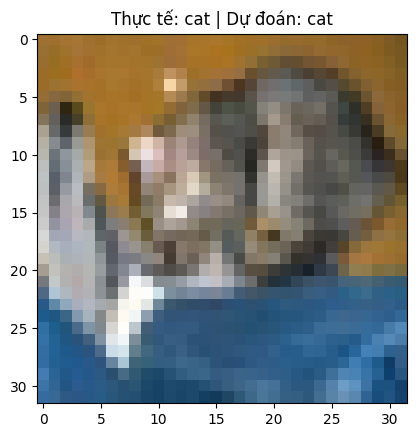

In [21]:
predict_output = model.predict(X_test[0:1])

predicted_class_idx = np.argmax(predict_output)
actual_class_idx = np.argmax(y_test[0])

print("\n--- KẾT QUẢ DỰ ĐOÁN THỬ NGHIỆM MẪU 1 ---")
print(f"Hệ thống dự đoán ảnh thuộc lớp: {class_names[predicted_class_idx]}")
print(f"Nhãn thực tế chính xác của ảnh: {class_names[actual_class_idx]}")
plt.imshow(X_test[0])
plt.title(f"Thực tế: {class_names[actual_class_idx]} | Dự đoán: {class_names[predicted_class_idx]}")
plt.show()